# Facility Location

The uncapacitated facility location problem (UFL): choose which candidate sites to open so that every customer's demand is served at minimum total cost, where cost is the fixed cost of opening sites plus demand-weighted transport distance.

This notebook is the formulation companion to the [live app](https://facility-location.griffith-pse.com).

## Formulation

**Sets**: $\mathcal{I}$ = candidate sites, $\mathcal{J}$ = customers.

**Decision variables**: $y_i \in \{0,1\}$ = 1 if site $i$ is opened; $x_{ij} \in [0,1]$ = fraction of customer $j$'s demand served from site $i$.

**Data**: $f_i$ = fixed cost of opening site $i$, $d_j$ = demand of customer $j$, $c_{ij}$ = unit transport cost from site $i$ to customer $j$ (Euclidean distance here).

$$\begin{aligned}
\min_{x, y} \quad & \sum_{i \in \mathcal{I}} f_i\, y_i + \sum_{i \in \mathcal{I}} \sum_{j \in \mathcal{J}} c_{ij}\, d_j\, x_{ij} \\
\text{s.t.} \quad & \sum_{i \in \mathcal{I}} x_{ij} = 1 \qquad \forall j \in \mathcal{J} \\
& x_{ij} \le y_i \qquad \forall i \in \mathcal{I},\, j \in \mathcal{J} \\
& y_i \in \{0,1\}, \quad x_{ij} \ge 0
\end{aligned}$$

This is the multi-source variant: a customer could split demand across open facilities, but with no capacity limits a split is never beneficial, so optimal assignments are single-source (up to exact-distance ties).

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo

N_SITES, N_CUSTOMERS, SEED = 12, 40, 0

rng = np.random.default_rng(SEED)
sites_x = rng.uniform(0.05, 1.95, N_SITES)
sites_y = rng.uniform(0.05, 0.95, N_SITES)
fixed = rng.uniform(0.4, 1.2, N_SITES)
cust_x = rng.uniform(0.0, 2.0, N_CUSTOMERS)
cust_y = rng.uniform(0.0, 1.0, N_CUSTOMERS)
demand = rng.uniform(0.5, 1.5, N_CUSTOMERS)

dist = np.hypot(sites_x[:, None] - cust_x[None, :],
                sites_y[:, None] - cust_y[None, :])

In [2]:
m = pyo.ConcreteModel()
m.I = pyo.RangeSet(0, N_SITES - 1)
m.J = pyo.RangeSet(0, N_CUSTOMERS - 1)
m.y = pyo.Var(m.I, within=pyo.Binary)
m.x = pyo.Var(m.I, m.J, bounds=(0, 1))

m.obj = pyo.Objective(
    expr=sum(fixed[i] * m.y[i] for i in m.I)
    + sum(dist[i, j] * demand[j] * m.x[i, j] for i in m.I for j in m.J),
    sense=pyo.minimize)

m.assign = pyo.Constraint(m.J, rule=lambda m, j: sum(m.x[i, j] for i in m.I) == 1)
m.linking = pyo.Constraint(m.I, m.J, rule=lambda m, i, j: m.x[i, j] <= m.y[i])

res = pyo.SolverFactory("appsi_gurobi").solve(m)
opened = [i for i in m.I if pyo.value(m.y[i]) > 0.5]
print(f"status: {res.solver.termination_condition}")
print(f"optimal cost: {pyo.value(m.obj):.2f}")
print(f"open sites: {[i + 1 for i in opened]}")

status: optimal
optimal cost: 15.78
open sites: [1, 2, 3, 5, 10]


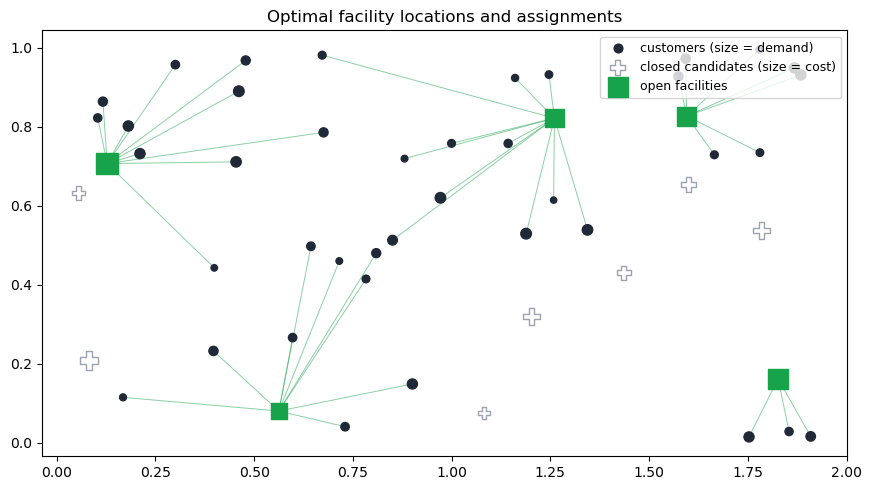

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
assign = {j: max(m.I, key=lambda i: pyo.value(m.x[i, j])) for j in m.J}
for j, i in assign.items():
    ax.plot([cust_x[j], sites_x[i]], [cust_y[j], sites_y[i]],
            color="#16a34a", lw=0.7, alpha=0.5, zorder=1)
ax.scatter(cust_x, cust_y, s=demand * 40, color="#1f2937", zorder=2,
           label="customers (size = demand)")
closed = [i for i in m.I if i not in opened]
ax.scatter(sites_x[closed], sites_y[closed], marker="P", s=fixed[closed] * 150,
           facecolors="none", edgecolors="#9ca3af", zorder=3,
           label="closed candidates (size = cost)")
ax.scatter(sites_x[opened], sites_y[opened], marker="s", s=fixed[opened] * 200,
           color="#16a34a", zorder=4, label="open facilities")
ax.set_aspect("equal"); ax.legend(loc="upper right", fontsize=9)
ax.set_title("Optimal facility locations and assignments")
plt.tight_layout()

## References

[1] A. A. Kuehn and M. J. Hamburger, "A Heuristic Program for Locating Warehouses," *Management Science*, vol. 9, no. 4, pp. 643-666, 1963.

[2] D. Erlenkotter, "A Dual-Based Procedure for Uncapacitated Facility Location," *Operations Research*, vol. 26, no. 6, pp. 992-1009, 1978.

[3] G. Cornuejols, G. L. Nemhauser, and L. A. Wolsey, "The Uncapacitated Facility Location Problem," in *Discrete Location Theory*, P. B. Mirchandani and R. L. Francis, Eds. New York: Wiley, 1990, pp. 119-171.

[4] M. L. Bynum et al., *Pyomo: Optimization Modeling in Python*, 3rd ed. Cham: Springer, 2021.